<a href="https://colab.research.google.com/github/spirosdouk/gaussian-heart-disease-classifier/blob/main/heart_disease_bayes_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
dataset = pd.read_csv('dataset.csv')
print(dataset)

      age  trestbps   chol  target
0    63.0     145.0  233.0       0
1    67.0     160.0  286.0       1
2    67.0     120.0  229.0       1
3    37.0     130.0  250.0       0
4    41.0     130.0  204.0       0
..    ...       ...    ...     ...
292  57.0     140.0  241.0       1
293  45.0     110.0  264.0       1
294  68.0     144.0  193.0       1
295  57.0     130.0  131.0       1
296  57.0     130.0  236.0       1

[297 rows x 4 columns]


A1.Compute the mean vector for each class


In [ ]:
heart_dis = dataset[dataset['target'] == 0]
noheart_dis = dataset[dataset['target'] == 1]
meanvec = heart_dis[['age', 'trestbps', 'chol']].mean()

meanvec2 = noheart_dis[['age', 'trestbps', 'chol']].mean()
print("has heart dis mean:\n", meanvec)
print("have no heart dis mean:\n", meanvec2)


has heart dis mean:
 age          52.64375
trestbps    129.17500
chol        243.49375
dtype: float64
have no heart dis mean:
 age          56.759124
trestbps    134.635036
chol        251.854015
dtype: float64


A2.Compute the covariance vector for each class

In [ ]:
covariance1 = heart_dis[['age', 'trestbps', 'chol']].cov()
covariance2 = noheart_dis[['age', 'trestbps', 'chol']].cov()
print("has heart dis covariance:\n", covariance1)
print("deos not have heart dis covariance:\n", covariance2)


has heart dis covariance:
                  age    trestbps         chol
age        91.224489   45.540723   124.007193
trestbps   45.540723  268.107547    91.076572
chol      124.007193   91.076572  2889.874175
deos not have heart dis covariance:
                 age    trestbps         chol
age       62.404787   36.190854    43.891048
trestbps  36.190854  357.086410   133.166917
chol      43.891048  133.166917  2468.096179


A3.Prior Prob

In [ ]:
datasetLen = len(dataset)
prior_prob_heart = len(heart_dis) / datasetLen
prior_prob_noheart = len(noheart_dis) / datasetLen
print(f"prior prob for has heart problems: {prior_prob_heart}")
print(f"prior prob for not having heart problems: {prior_prob_noheart}")

prior prob for has heart problems: 0.5387205387205387
prior prob for not having heart problems: 0.4612794612794613


A4.Posterior Prob

In [ ]:
import numpy as np
def likelihood(data, mean, cov):
    diffrence = data - mean
    # quadratic distance between data and mean by covariance
    quad = diffrence @ np.linalg.solve(cov, diffrence)

    normalization = 1.0 / np.sqrt(((2 * np.pi) ** data.size) * np.linalg.det(cov))

    return normalization * np.exp(-0.5 * quad)


def compute_posterior_probabilities(data, mean1, cov1, prior1, mean2, cov2, prior2):
    posterior2 = []
    posterior1 = []

    for i, row in data.iterrows():
        # likelihood for each class
        likelihood1 = likelihood(row[['age', 'trestbps', 'chol']].to_numpy(), np.array(mean1), np.array(cov1))
        score1 = likelihood1 * prior1
        likelihood2 = likelihood(row[['age', 'trestbps', 'chol']].to_numpy(), np.array(mean2), np.array(cov2))
        score2 = likelihood2 * prior2
        # turn scores into probabilities that add up to 1
        total_score = score1 + score2
        normaluize1 = score1 / total_score
        normaluize2 = score2 / total_score

        posterior2.append(normaluize1)
        posterior1.append(normaluize2)

    return posterior1, posterior2

posterior1, posterior2 = compute_posterior_probabilities(dataset,meanvec, covariance1, prior_prob_heart, meanvec2, covariance2, prior_prob_noheart)

dataset['posterior1'] = posterior1
print("has heart dis posterior:\n", dataset[['posterior1']].head())
dataset['posterior2'] = posterior2
print("does not have heart dis Posterior:\n", dataset[['posterior2']].head())

has heart dis posterior:
    posterior1
0    0.590708
1    0.688482
2    0.554134
3    0.160593
4    0.191229
does not have heart dis Posterior:
    posterior2
0    0.409292
1    0.311518
2    0.445866
3    0.839407
4    0.808771


A5.Predicted class for each sample

In [ ]:
predicted_class = []

for i in range(len(dataset)):
    # choose the class with the bigger posterior
    if posterior1[i] > posterior2[i]:
        predicted_class.append(0)
    else:
        predicted_class.append(1)

dataset['predicted_class'] = predicted_class
correct = 0
# compute accuracy
for i in range(len(dataset)):
    if dataset['predicted_class'].iloc[i] == dataset['target'].iloc[i]:
        correct += 1

accuracy = correct / len(dataset)
print(dataset[['age', 'trestbps', 'chol', 'target', 'predicted_class']])
print("accuracy:", accuracy)


      age  trestbps   chol  target  predicted_class
0    63.0     145.0  233.0       0                0
1    67.0     160.0  286.0       1                0
2    67.0     120.0  229.0       1                0
3    37.0     130.0  250.0       0                1
4    41.0     130.0  204.0       0                1
..    ...       ...    ...     ...              ...
292  57.0     140.0  241.0       1                0
293  45.0     110.0  264.0       1                1
294  68.0     144.0  193.0       1                0
295  57.0     130.0  131.0       1                1
296  57.0     130.0  236.0       1                0

[297 rows x 5 columns]
accuracy: 0.37373737373737376


B.1 Σε αυτήν την περίπτωση, αν heart disease, ένα false negative αποτέλεσμα (η πρόβλεψη μη ύπαρξης ασθένειας όταν ο ασθενής έχει κάποια ασθένεια) είναι πολύ πιο επικίνδυνο, επειδή μπορεί να επηρεάσει την υγεία του και να οδηγήσει σε θάνατο. Ένα false positive αποτέλεσμα (η πρόβλεψη ασθένειας όταν δεν υπάρχει ασθένεια) μπορεί να οδηγήσει σε περισσότερες εξετάσεις, αρά είναι προτιμότερο από το να μην υπάρξει κάποιο κρούσμα. Έτσι, η L3[[0,1],[5,0]] είναι η καλύτερη επιλογή.

In [ ]:
lambda3 = np.array([[0, 1],[5, 0]])

In [ ]:
def compute_risks(posterior1, posterior2):
    risks1 = []
    risks2 = []
    #loop to compute risk based on lamda3
    for i in range(len(posterior1)):
        posteriors1 = posterior1[i]
        posteriors2 = posterior2[i]

        risk1 = lambda3[0][0]*posteriors1 + lambda3[0][1]*posteriors2
        risk2 = lambda3[1][0]*posteriors1 + lambda3[1][1]*posteriors2

        risks1.append(risk1)
        risks2.append(risk2)

    return risks1, risks2


risk1, risk2 = compute_risks(posterior1, posterior2)

for i in range(len(posterior1)):
    print("Sample", i, "risk1:", risk1[i], "risk2:", risk2[i])


Sample 0 risk1: 0.4092919482771021 risk2: 2.95354025861449
Sample 1 risk1: 0.31151834051695665 risk2: 3.4424082974152164
Sample 2 risk1: 0.44586646619226217 risk2: 2.770667669038689
Sample 3 risk1: 0.8394066855071902 risk2: 0.8029665724640483
Sample 4 risk1: 0.8087711028239023 risk2: 0.9561444858804884
Sample 5 risk1: 0.5166399935931676 risk2: 2.4168000320341623
Sample 6 risk1: 0.4349335791436385 risk2: 2.825332104281808
Sample 7 risk1: 0.5805282741678156 risk2: 2.0973586291609214
Sample 8 risk1: 0.461692410382045 risk2: 2.6915379480897745
Sample 9 risk1: 0.5476171688581216 risk2: 2.2619141557093916
Sample 10 risk1: 0.5023533035397715 risk2: 2.4882334823011427
Sample 11 risk1: 0.46506941610678537 risk2: 2.6746529194660735
Sample 12 risk1: 0.5060671592560977 risk2: 2.469664203719512
Sample 13 risk1: 0.7117669269198721 risk2: 1.4411653654006396
Sample 14 risk1: 0.31306964993568837 risk2: 3.434651750321558
Sample 15 risk1: 0.4878909209132472 risk2: 2.5605453954337642
Sample 16 risk1: 0.63

B.3 predicted class for each sample

In [ ]:
predicted_class_risk = []
# loop to find conditional risk
for i in range(len(risk1)):
    risk_1 = risk1[i]
    risk_2 = risk2[i]

    if risk_1 < risk_2:
        predicted_class_risk.append(0)
    else:
        predicted_class_risk.append(1)

dataset['predicted_class_risk'] = predicted_class_risk

print(dataset[['target', 'predicted_class_risk']])

     target  predicted_class_risk
0         0                     0
1         1                     0
2         1                     0
3         0                     1
4         0                     0
..      ...                   ...
292       1                     0
293       1                     0
294       1                     0
295       1                     0
296       1                     0

[297 rows x 2 columns]


B.4 Το accuracy έπεσε στο Β ερώτημα, αλλά είναι το πιο σωστό να επιλεχθρί, καθώς δίνει προτεραιότητα στην αποφυγή του λάθους (κάποιος να έχει hearτ disease και να μην ανιχνεύεται), το οποίο είναι πιο κακό.

In [ ]:
correct = 0
target_list = dataset['target'].to_list()
pred_list = dataset['predicted_class_risk'].to_list()

# to calc accuracy
for i in range(len(dataset)):
    if pred_list[i] == target_list[i]:
        correct += 1

print("max posterior rile:", accuracy)
accuracy_risk = correct / len(dataset)
print("risk based accuracy:", accuracy_risk)

max posterior rile: 0.37373737373737376
risk based accuracy: 0.5286195286195287


C1.distibution of classes

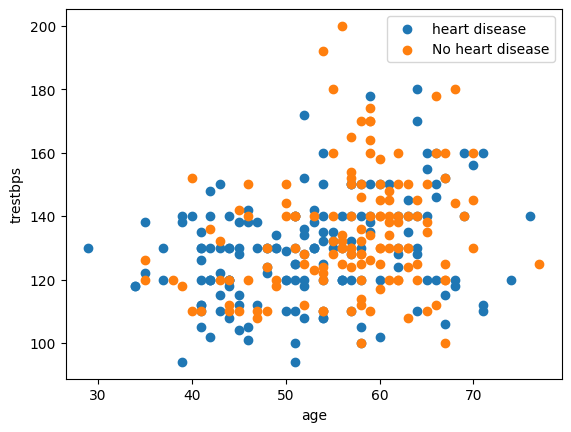

In [ ]:
import matplotlib.pyplot as plt
# the 2 classes
heart_dis = dataset[dataset['target'] == 0]
no_heart_dis = dataset[dataset['target'] == 1]
# scatter plot
plt.scatter(heart_dis['age'], heart_dis['trestbps'], label='heart disease')
plt.scatter(no_heart_dis['age'], no_heart_dis['trestbps'], label='No heart disease')

plt.xlabel('age')
plt.ylabel('trestbps')
plt.legend()
plt.show()


C2.Plot mean

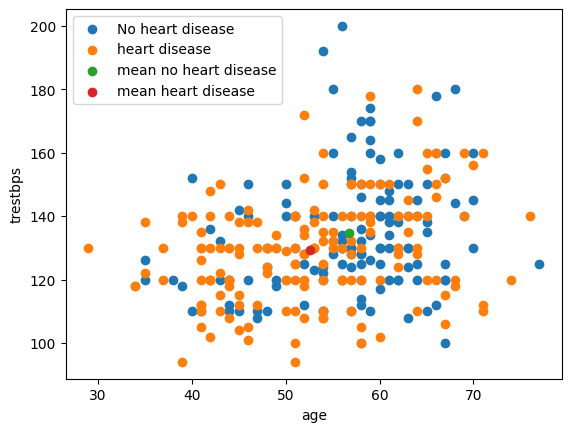

In [ ]:
plt.scatter(no_heart_dis['age'], no_heart_dis['trestbps'], label='No heart disease')
plt.scatter(heart_dis['age'], heart_dis['trestbps'], label='heart disease')
# means for each class
mean_trestbps_heart = heart_dis['trestbps'].mean()
mean_trestbps_no = no_heart_dis['trestbps'].mean()
mean_age_no = no_heart_dis['age'].mean()
mean_age_heart = heart_dis['age'].mean()
# scatter mean plot
plt.scatter(mean_age_no, mean_trestbps_no, label='mean no heart disease')
plt.scatter(mean_age_heart, mean_trestbps_heart, label='mean heart disease')

plt.xlabel('age')
plt.ylabel('trestbps')
plt.legend()
plt.show()


C3.decision boundary using the full covariance matrices

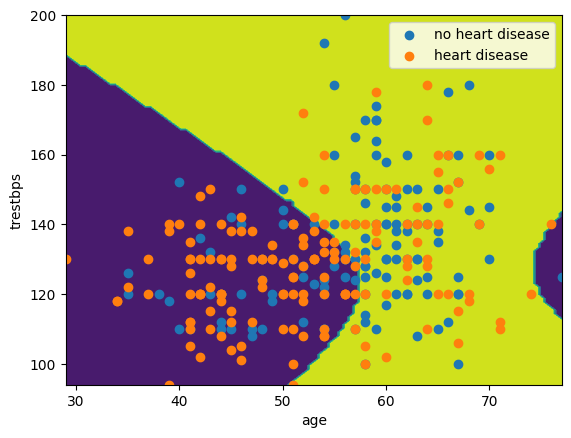

In [ ]:
chol_fixed = dataset["chol"].mean()

trestbps_values = np.linspace(dataset["trestbps"].min(), dataset["trestbps"].max(), 100)
age_values = np.linspace(dataset["age"].min(), dataset["age"].max(), 100)
age_grid, trestbps_grid = np.meshgrid(age_values, trestbps_values)
class_grid = np.zeros(age_grid.shape)

size = len(trestbps_values)
sizeage = len(age_values)
# go through the grid
for i in range(size):
    for j in range(sizeage):
        age_val = age_grid[i, j]
        trestbps_val = trestbps_grid[i, j]

        sample = np.array([age_val, trestbps_val, chol_fixed])
        score1 = likelihood(sample, meanvec, covariance1) * prior_prob_heart
        score2 = likelihood(sample, meanvec2, covariance2) * prior_prob_noheart
        #choose the class with the bigger score(likelihood * prior)
        if score1 > score2:
          class_grid[i, j] = 0
        else:
          class_grid[i, j] = 1

# plot the decision regions + the real points
plt.contourf(age_grid, trestbps_grid, class_grid)

plt.scatter(no_heart_dis["age"], no_heart_dis["trestbps"], label="no heart disease")
plt.scatter(heart_dis["age"], heart_dis["trestbps"], label="heart disease")

plt.xlabel("age")
plt.ylabel("trestbps")
plt.legend()
plt.show()


C4.Στο διάγραμμα οι δύο κλάσεις κανουν overlap αρκετά, και τα δεδομένα δεν είναι εύκολα διαχωρίσιμα μόνο με τα δυο αύτα χαρακτηριστικά age και trestbps. Αυτό συμβαίνει γιατί το heart disease εξαρτάται από περισσότερους παράγοντες και όχι μόνο από αυτά τα δύο.
